In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import savgol_filter
from collections import deque

/Users/klavikka/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:

#log_file = "logs/2020-04-14.log"
#log_file = "logs/2020-12-24.log"
#log_file = "logs/2021-01-01.log"
#log_file = "logs/2020-12-17.log" # Hankala
#log_file = "logs/2020-11-22.log" 
#log_file = "logs/2020-10-30.log" # Jees
#log_file = "logs/2020-09-30.log"
log_file = "logs/2025-01-07.log"

In [3]:

class TemperatureMonitor:
    # Define states
    REST = "REST"
    WARMING = "WARMING"
    COOLING = "COOLING"

    def __init__(
        self,
        window_length=11,
        polyorder=2,
        delta=0.333,
        warming_derivative_threshold=0.1,
        cooling_temperature_threshold=60.0,
        cooling_time_threshold=60,
        rest_temperature_threshold=30.0,
        alert_threshold_derivative=0.7,
        alert_threshold_second_derivative=-0.05,
        max_alert_frequency=3,
    ):
        """
        Initialize the temperature monitor with states and alert logic.
        
        Args:
            window_length (int): Window size for the Savitzky-Golay filter (must be odd).
            polyorder (int): Polynomial order for the Savitzky-Golay filter.
            delta (float): Time interval between measurements.
            warming_derivative_threshold (float): Threshold for transitioning to WARMING.
            cooling_temperature_threshold (float): Temperature to transition to COOLING.
            cooling_time_threshold (int): Time in minutes until transitioning to COOLING.
            rest_temperature_threshold (float): Temperature to transition back to REST.
            alert_threshold_derivative (float): Alert if the first derivative is less than this value.
            alert_threshold_second_derivative (float): Alert if the second derivative is less than this value.
            max_alert_frequency (int): Minimum seconds between consecutive alerts.
        """
        self.window_length = window_length
        self.polyorder = polyorder
        self.delta = delta
        self.warming_derivative_threshold = warming_derivative_threshold
        self.cooling_temperature_threshold = cooling_temperature_threshold
        self.cooling_time_threshold = cooling_time_threshold
        self.rest_temperature_threshold = rest_temperature_threshold
        self.alert_threshold_derivative = alert_threshold_derivative
        self.alert_threshold_second_derivative = alert_threshold_second_derivative
        self.max_alert_frequency = max_alert_frequency

        self.buffer = deque(maxlen=window_length)
        self.state = self.REST
        self.state_start_time = None
        self.last_alert_time = None  # Timestamp of the last alert
    
    def _change_state(self, new_state, timestamp):
        """Change the state and record the time."""
        self.state = new_state
        self.state_start_time = timestamp

    def add_measurement(self, timestamp, temperature):
        """
        Add a new measurement and process it.
        
        Args:
            timestamp (float): Time of the measurement.
            temperature (float): Temperature value.
        
        Returns:
            dict: Calculated values including smoothed temperature, first derivative,
                  second derivative, state, and alert status.
        """
        self.buffer.append((timestamp, temperature))
        
        # Ensure we have enough data to apply the Savitzky-Golay filter
        if len(self.buffer) < self.window_length:
            return {
                "smoothed_temperature": None,
                "first_derivative": None,
                "second_derivative": None,
                "state": self.state,
                "alert": False,
            }
        
        # Extract timestamps and temperatures from the buffer
        timestamps, temperatures = zip(*self.buffer)
        timestamps = np.array(timestamps)
        temperatures = np.array(temperatures)
        
        # Apply Savitzky-Golay filter
        smoothed_temperature = savgol_filter(temperatures, window_length=self.window_length, polyorder=self.polyorder)[-1]
        first_derivative = savgol_filter(temperatures, window_length=self.window_length, polyorder=self.polyorder, deriv=1, delta=self.delta)[-1]
        second_derivative = savgol_filter(temperatures, window_length=self.window_length, polyorder=self.polyorder, deriv=2, delta=self.delta)[-1]
        
        # State transitions
        if self.state == self.REST:
            if first_derivative > self.warming_derivative_threshold:
                self._change_state(self.WARMING, timestamp)
        
        elif self.state == self.WARMING:
            if smoothed_temperature >= self.cooling_temperature_threshold or \
               (self.state_start_time is not None and timestamp - self.state_start_time >= self.cooling_time_threshold):
                self._change_state(self.COOLING, timestamp)
        
        elif self.state == self.COOLING:
            if smoothed_temperature <= self.rest_temperature_threshold:
                self._change_state(self.REST, timestamp)
        
        # Alert logic
        alert = (
            self.state == self.WARMING and
            first_derivative < self.alert_threshold_derivative and
            second_derivative < self.alert_threshold_second_derivative and
            (self.last_alert_time is None or timestamp - self.last_alert_time > self.max_alert_frequency)
        )
        if alert:
            self.last_alert_time = timestamp

        return {
            "smoothed_temperature": smoothed_temperature,
            "first_derivative": first_derivative,
            "second_derivative": second_derivative,
            "state": self.state,
            "alert": alert,
        }

In [4]:
df = pd.read_csv(log_file, sep="\t", header=None, names=["timestamp", "temperature", "derivative"])


In [13]:
monitor = TemperatureMonitor(window_length=16, polyorder=2, delta=0.33, alert_threshold_derivative=0.7)

# Process each measurement and record results
alerts = []
df["smoothed_temperature"] = None
df["first_derivative"] = None
df["second_derivative"] = None
df["alert"] = None

# Initialize variables to track state transitions
state_transitions = []
previous_state = TemperatureMonitor.REST

for index, row in df.iterrows():
    result = monitor.add_measurement(row["timestamp"], row["temperature"])
    df.at[index, "smoothed_temperature"] = result["smoothed_temperature"]
    df.at[index, "first_derivative"] = result["first_derivative"]
    df.at[index, "second_derivative"] = result["second_derivative"]
    df.at[index, "alert"] = result["alert"]
    
    if result["alert"]:
        alerts.append((row["timestamp"], result["smoothed_temperature"]))
    
    # Check for state transition
    current_state = result["state"]
    if current_state != previous_state:
        state_transitions.append((row["timestamp"], current_state))
        previous_state = current_state

# Extract state change timestamps and states
state_change_timestamps, state_change_states = zip(*state_transitions) if state_transitions else ([], [])

# Convert to numeric to handle None values
df["smoothed_temperature"] = pd.to_numeric(df["smoothed_temperature"], errors="coerce")
df["first_derivative"] = pd.to_numeric(df["first_derivative"], errors="coerce")
df["second_derivative"] = pd.to_numeric(df["second_derivative"], errors="coerce")
df["alert"] = df["alert"].astype(bool)

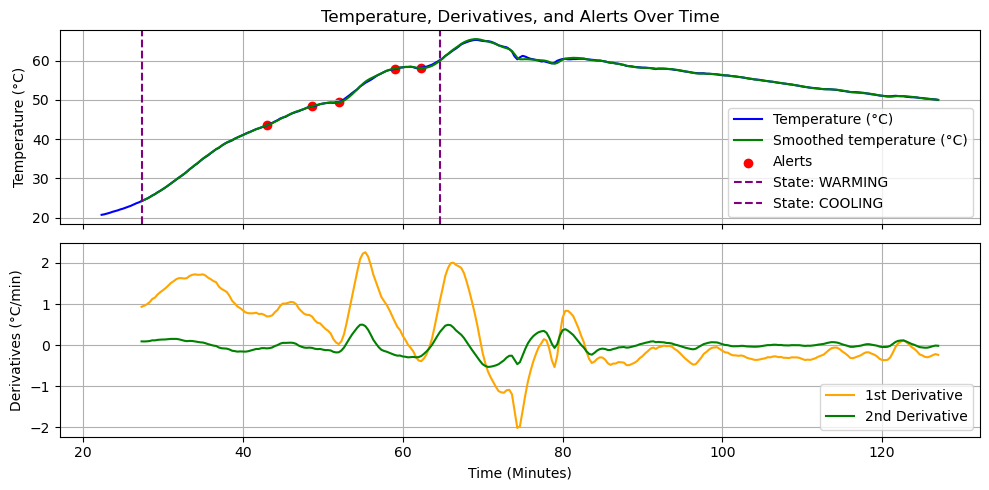

In [14]:
# Extract alert points for plotting
alert_timestamps, alert_temperatures = zip(*alerts) if alerts else ([], [])

# Create subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 5), sharex=True, gridspec_kw={'height_ratios': [5, 5]})

# Plot temperature on the first axis
ax1.plot(df["timestamp"], df["temperature"], label="Temperature (°C)", color="blue")
ax1.plot(df["timestamp"], df["smoothed_temperature"], label="Smoothed temperature (°C)", color="green")
ax1.scatter(alert_timestamps, alert_temperatures, color="red", label="Alerts")

# Draw vertical lines for state changes
for timestamp, state in zip(state_change_timestamps, state_change_states):
    ax1.axvline(timestamp, color="purple", linestyle="--", label=f"State: {state}")

ax1.set_ylabel("Temperature (°C)")
ax1.set_title("Temperature, Derivatives, and Alerts Over Time")
ax1.legend(loc="lower right")
ax1.grid(True)

# Plot derivatives on the second axis
ax2.plot(df["timestamp"], df["first_derivative"], label="1st Derivative", color="orange")
ax2.plot(df["timestamp"], df["second_derivative"], label="2nd Derivative", color="green")

ax2.set_ylabel("Derivatives (°C/min)")
ax2.legend(loc="lower right")
ax2.grid(True)
ax2.set_xlabel("Time (Minutes)")

# Adjust layout
plt.tight_layout()
plt.show()
